In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass" , "sex" , "fare" , "embarked" , "age"]
target = ["survived"]

In [5]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic.shape

(891, 15)

In [8]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [31]:
X = titanic[features]
Y = titanic["survived"]

In [32]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 42
)

In [37]:
# Decision Tree Model --> no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 4)
model.fit(X_train , Y_train)

DecisionTreeClassifier(max_depth=4)

In [38]:
from sklearn.metrics import accuracy_score

Y_pred_train = model.predict(X_train)
Y_pred = model.predict(X_test)

print(f"Train Accuracy Score : {accuracy_score(Y_train , Y_pred_train)}")
print(f"Test Accuracy Score : {accuracy_score(Y_test , Y_pred)}")

Train Accuracy Score : 0.8398876404494382
Test Accuracy Score : 0.7988826815642458


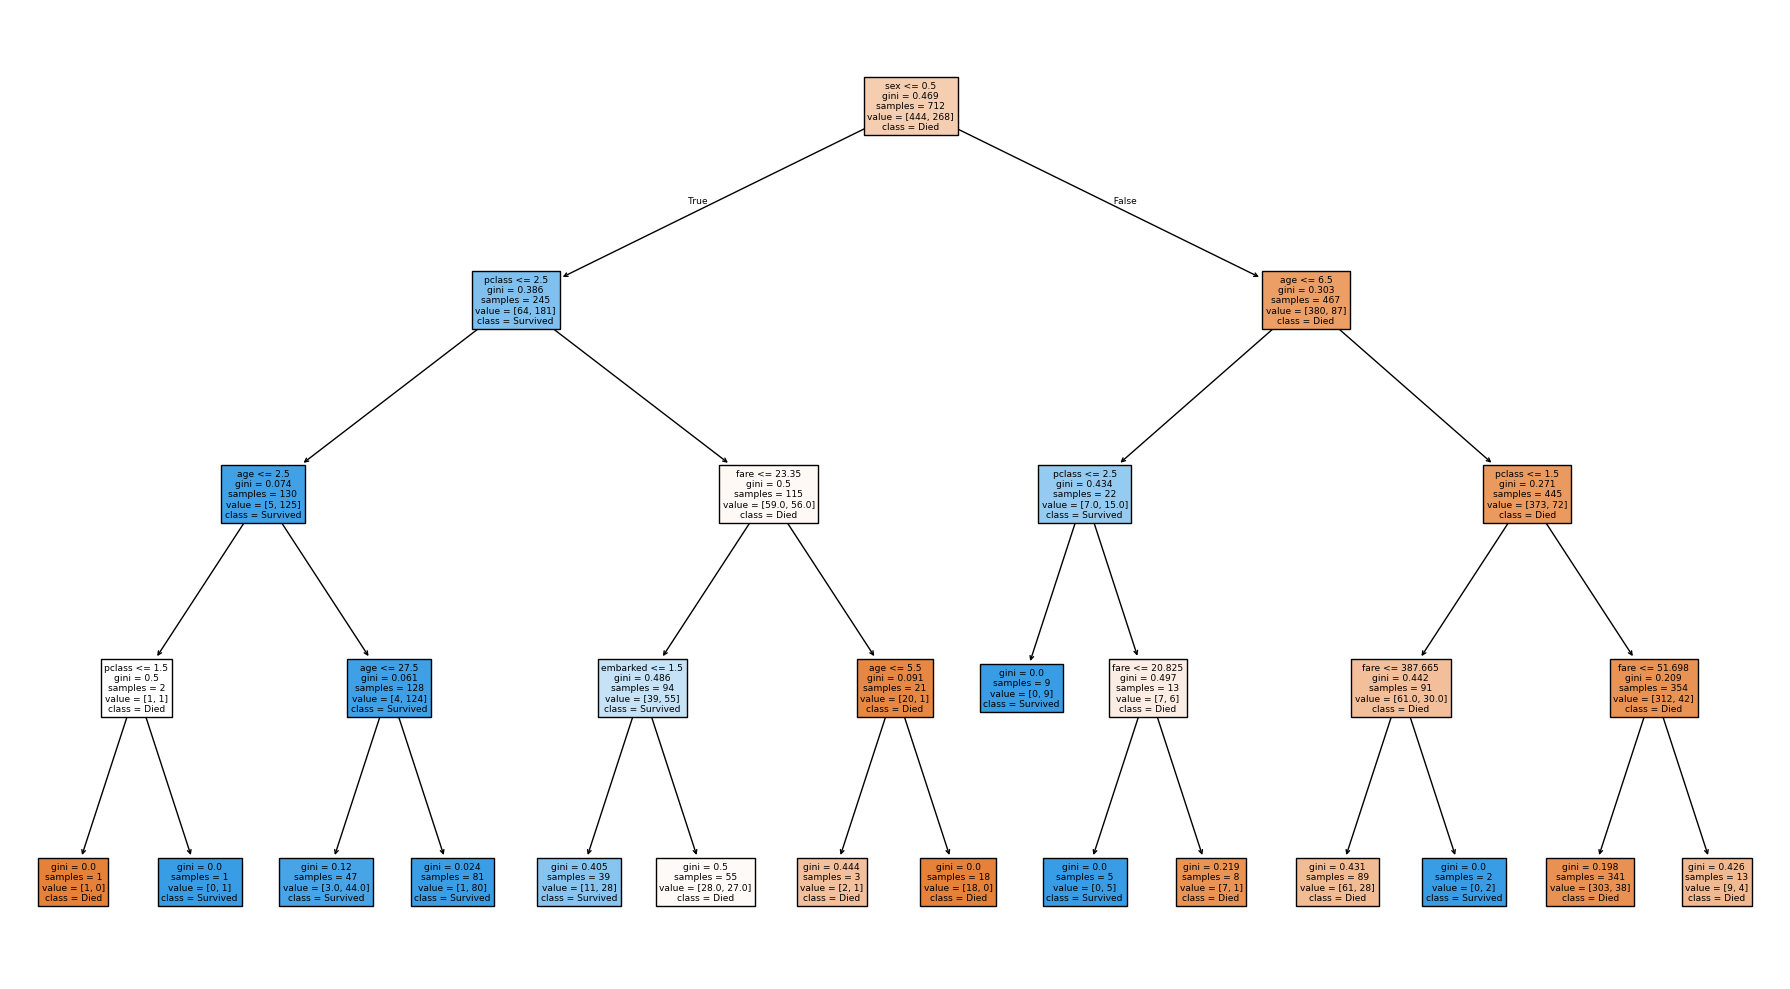

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18 , 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died" , "Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

In [41]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 201  ,
    oob_score = True,
    max_depth = 4
)

rf.fit(X_train , Y_train)
y_pred = rf.predict(X_test)
y_train_pred = rf.predict(X_train);

print(f"OOB Score : {rf.oob_score_}")
print(f"Testing accuracy : {accuracy_score(Y_test , y_pred)}")
print(f"Train accuracy : {accuracy_score(Y_train , y_train_pred)}")

OOB Score : 0.8230337078651685
Testing accuracy : 0.8212290502793296
Train accuracy : 0.851123595505618


Depth : 2 , Accuracy : 0.7653631284916201
Depth : 3 , Accuracy : 0.7988826815642458
Depth : 4 , Accuracy : 0.7988826815642458


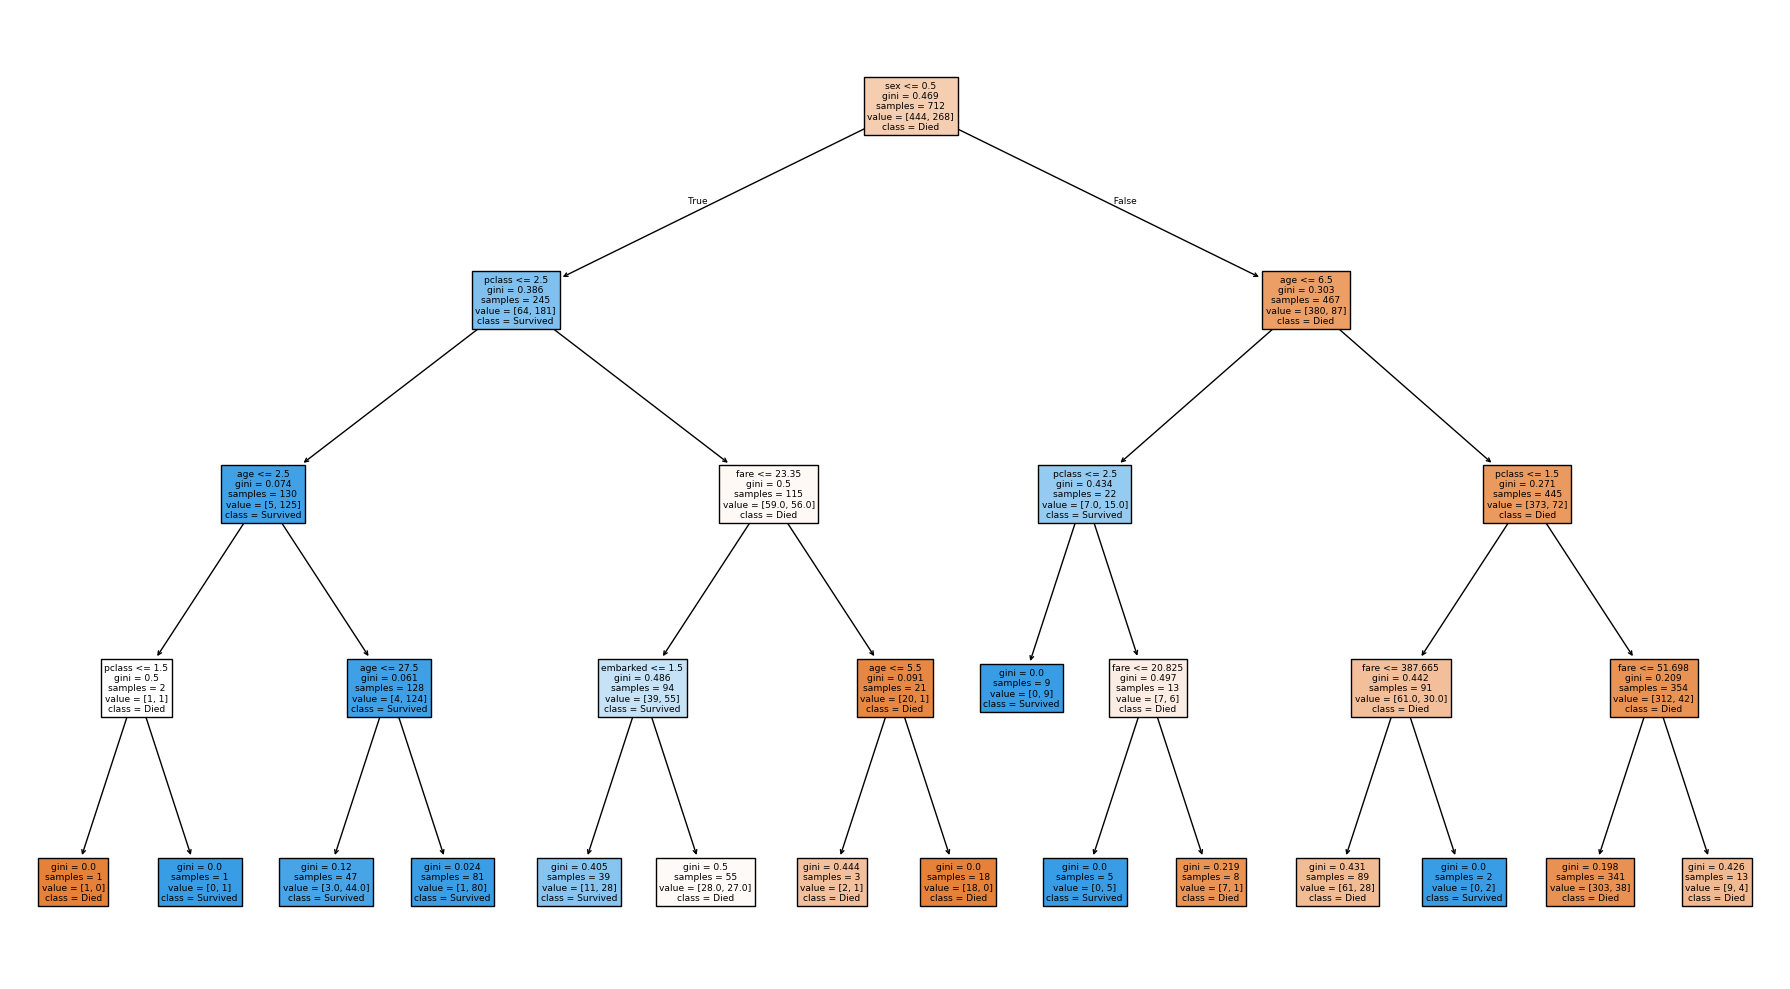

Depth : 5 , Accuracy : 0.7988826815642458
Depth : 6 , Accuracy : 0.8044692737430168
Depth : 7 , Accuracy : 0.8044692737430168
Depth : 8 , Accuracy : 0.7877094972067039
Depth : 9 , Accuracy : 0.7988826815642458
Depth : 10 , Accuracy : 0.7932960893854749


In [15]:
# Decision Tree with pre-pruning
max_depth = [2 , 3, 4, 5,6 ,7, 8 , 9, 10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train , Y_train)

    acc = model.score(X_test , Y_test)
    print(f"Depth : {depth} , Accuracy : {acc}")

    if depth == 4:
        plt.figure(figsize = (18 , 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died" , "Survived"],
            filled = True
        )
        
        plt.tight_layout()
        plt.show()

Splits : 10 , Accuracy : 0.7988826815642458


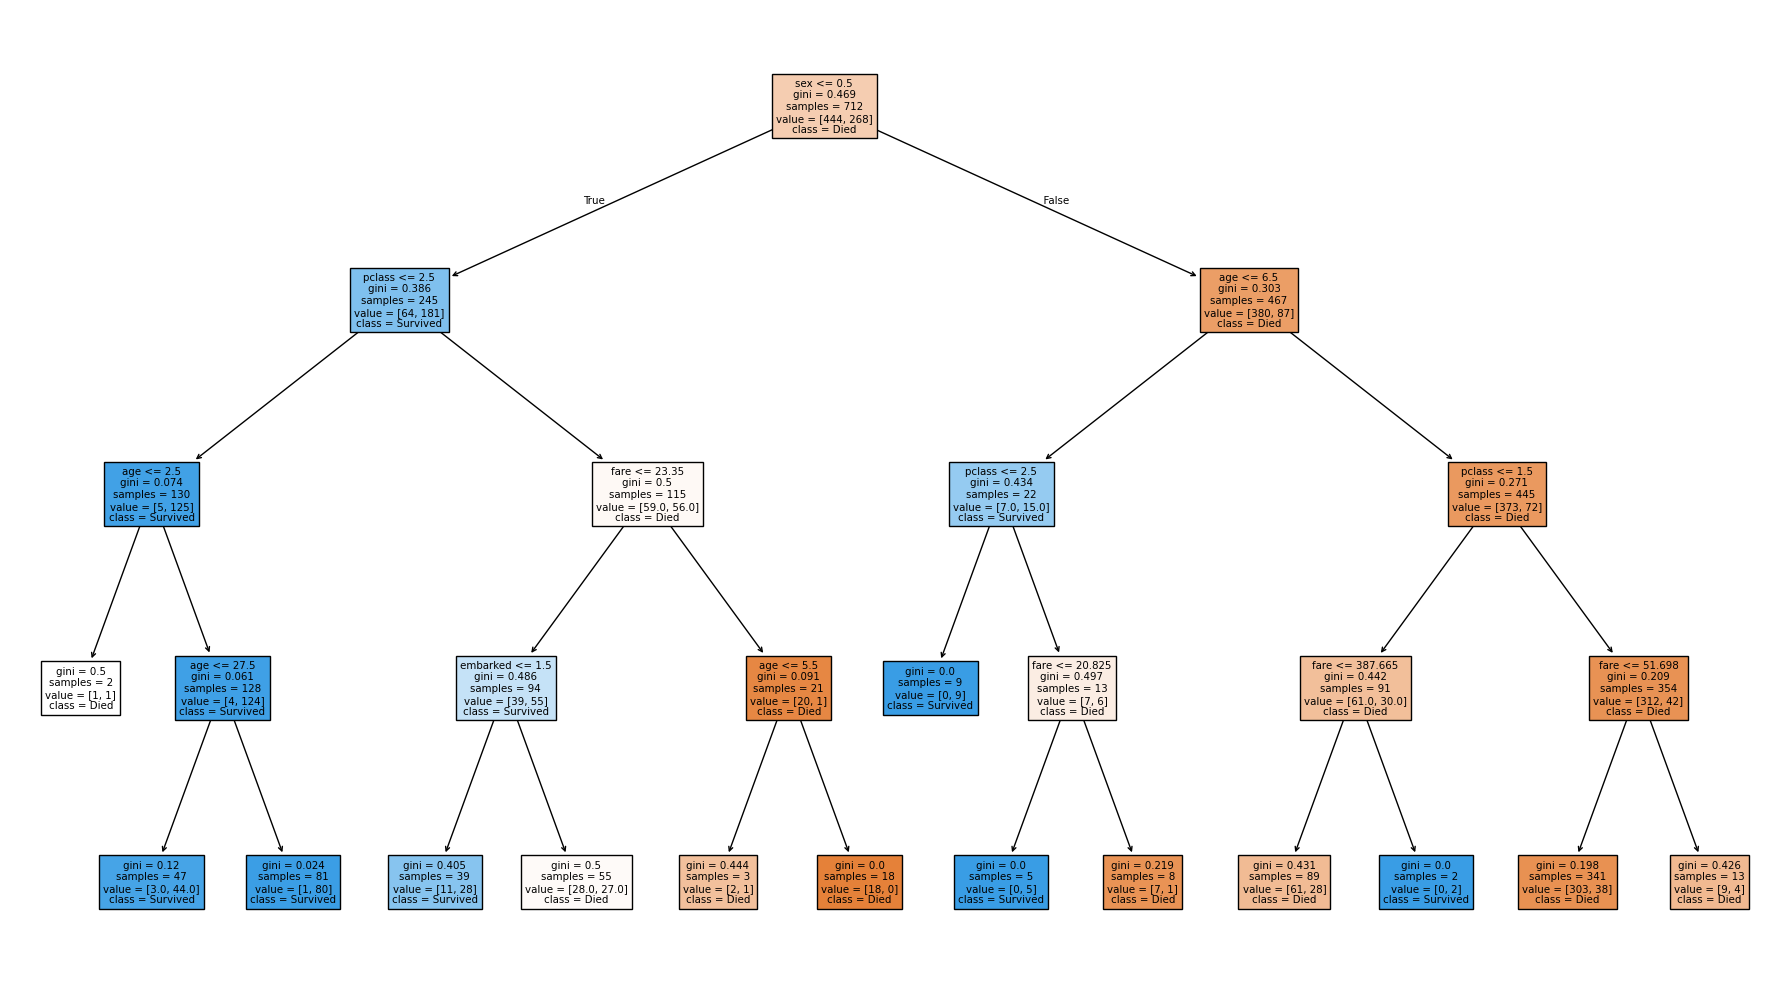

Splits : 15 , Accuracy : 0.7988826815642458
Splits : 20 , Accuracy : 0.7988826815642458
Splits : 25 , Accuracy : 0.7932960893854749
Splits : 30 , Accuracy : 0.7932960893854749


In [16]:
min_sample_splits = [10 , 15, 20, 25, 30]
for splits in min_sample_splits:
    model = DecisionTreeClassifier(max_depth = 4 , min_samples_split = splits)
    model.fit(X_train , Y_train)

    acc = model.score(X_test , Y_test)
    print(f"Splits : {splits} , Accuracy : {acc}")

    if splits == 10:
        plt.figure(figsize = (18 , 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died" , "Survived"],
            filled = True
        )
        
        plt.tight_layout()
        plt.show()

Decision Tree with post-pruning


In [17]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train , Y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
path = full_tree.cost_complexity_pruning_path(X_train , Y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [19]:
# train model for all alphas
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha = alpha)
    model.fit(X_train , Y_train)

    tree.append([model , alpha])

best_acc = 0
best_alpha= 0

for model, alpha in tree:
    curr_acc = model.score(X_test , Y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [20]:
print(f"Best alpha is {best_alpha} , Best accuracy is {best_acc}")

Best alpha is 0.0015407231242023183 , Best accuracy is 0.8379888268156425


In [21]:
best_model =  DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train , Y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

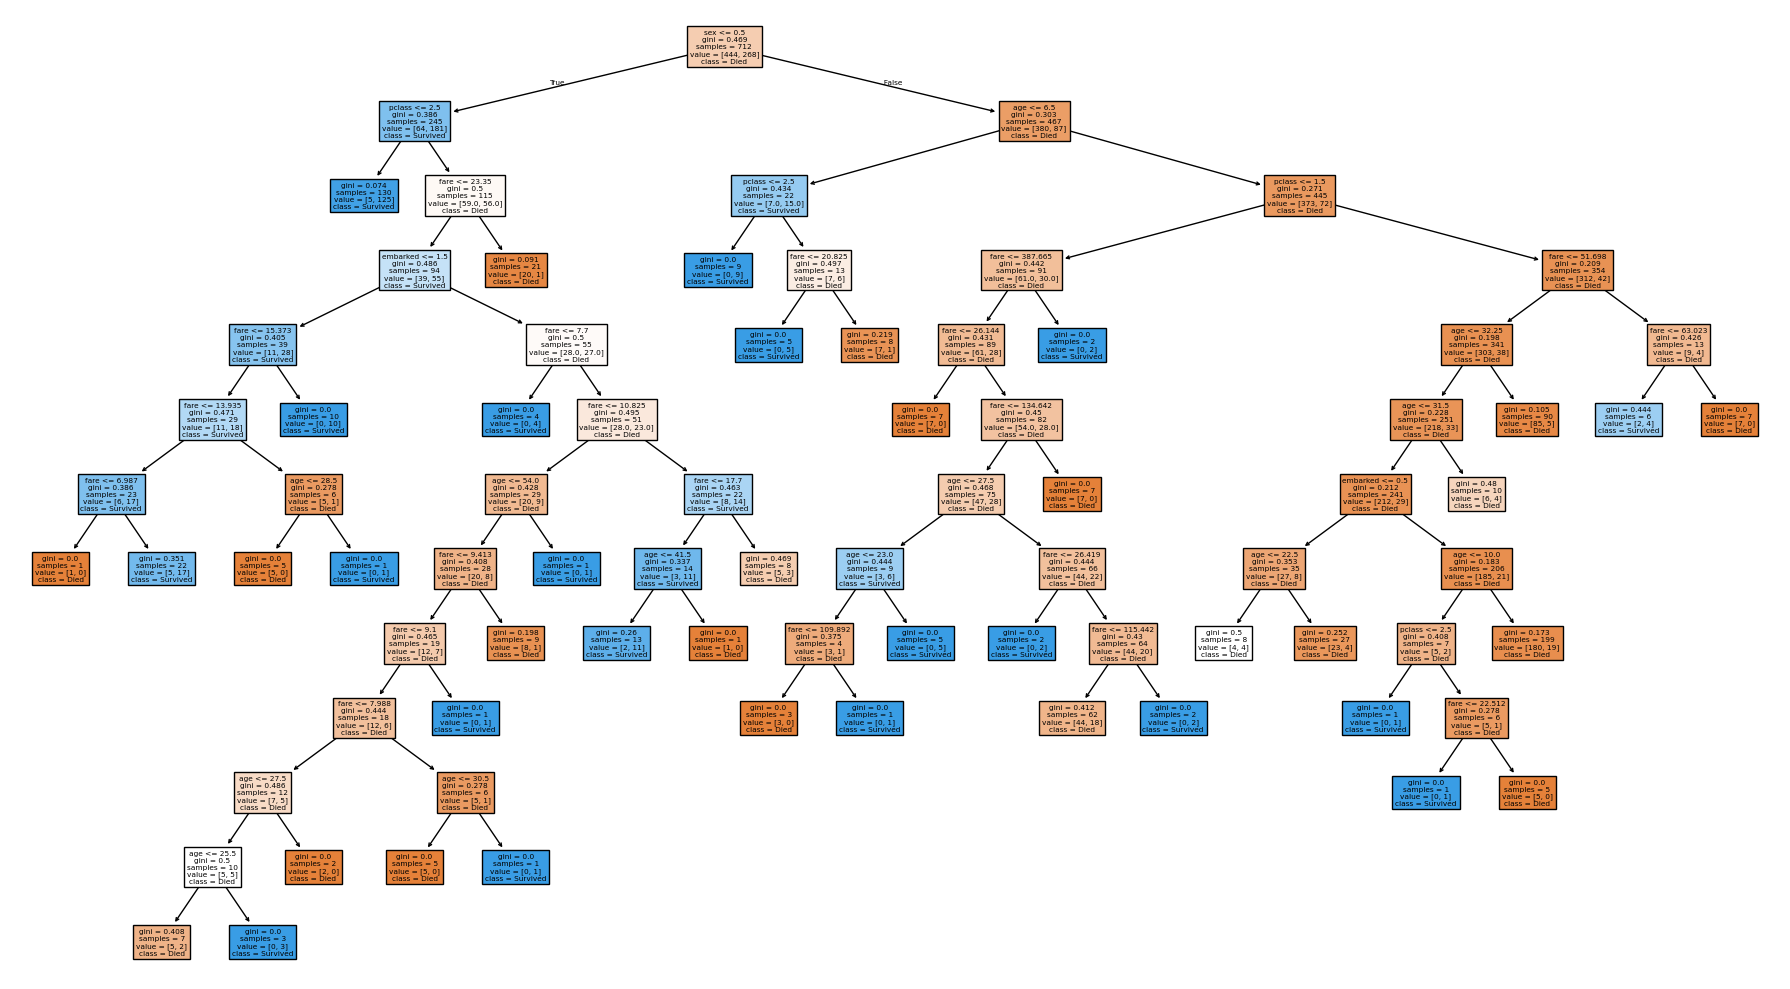

In [22]:
plt.figure(figsize = (18 , 10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died" , "Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

In [23]:
print(best_model.score(X_test , Y_test))

0.8379888268156425


In [44]:
#Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model =  DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train , Y_train)

y_pred = bagging.predict(X_test);

print(f"Accuracy : {accuracy_score(Y_test , y_pred)}")

Accuracy : 0.8044692737430168
